# Потеряйло Вероніка ФЕ-41 Лабораторна робота №3 - Візуалізація даних

## **Завдання:**
* Обрати унікальний датасет (обрано Automobile Data Set);
* Здійснити Data Cleaning;
* Побудувати графіки залежності одного атрибута від іншого (lineplot, scatter etc);
* Побудувати гістограму по одному з атрибутів за заданими діапазонами;
* Побудувати графіки багатовимірної візуалізації (multi-dimensional visualization);
* Загальна кількість графіків має становити 5-8.

Інсталюємо та імпортуємо наступні бібліотеки:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

Завантажуємо датасет Automobile з локального файлу `automobile.csv` (раніше `imports-85.data`) та задаємо назви стовпців згідно зі специфікацією:

In [2]:
cols = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location",
    "wheel-base", "length", "width", "height", "curb-weight", "engine-type",
    "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
    "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"
]

file_path = os.path.join("automobile", "imports-85.data")
df = pd.read_csv(file_path, names=cols)

print(f"дані завантажно, розмірність: {df.shape}")
display(df.head())

дані завантажно, розмірність: (205, 26)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


Здійснюємо Data cleaning

In [3]:
def clean_auto_data(data):
    # Заміна '?' на NaN
    data = data.replace('?', np.nan)

    # Конвертація у числові типи
    numeric_cols = ["normalized-losses", "bore", "stroke", "horsepower", "peak-rpm", "price"]
    for col in numeric_cols:
        data[col] = pd.to_numeric(data[col], errors='coerce')

    # Видалення рядків без ціни
    data = data.dropna(subset=["price"], axis=0)

    # Заповнення пропусків
    data["normalized-losses"] = data["normalized-losses"].fillna(data["normalized-losses"].mean())
    data["bore"] = data["bore"].fillna(data["bore"].mean())
    data["stroke"] = data["stroke"].fillna(data["stroke"].mean())
    data["horsepower"] = data["horsepower"].fillna(data["horsepower"].mean())
    data["peak-rpm"] = data["peak-rpm"].fillna(data["peak-rpm"].mean())
    data["num-of-doors"] = data["num-of-doors"].fillna(data["num-of-doors"].mode()[0])

    # Скидаємо індекси після видалення
    data = data.reset_index(drop=True)
    return data

df = clean_auto_data(df)
print(f"data cleaned, розмірність: {df.shape}")
display(df.head())

data cleaned, розмірність: (201, 26)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


### **Візуалізація даних**
Будуємо серію графіків для аналізу залежностей характеристик автомобілів.

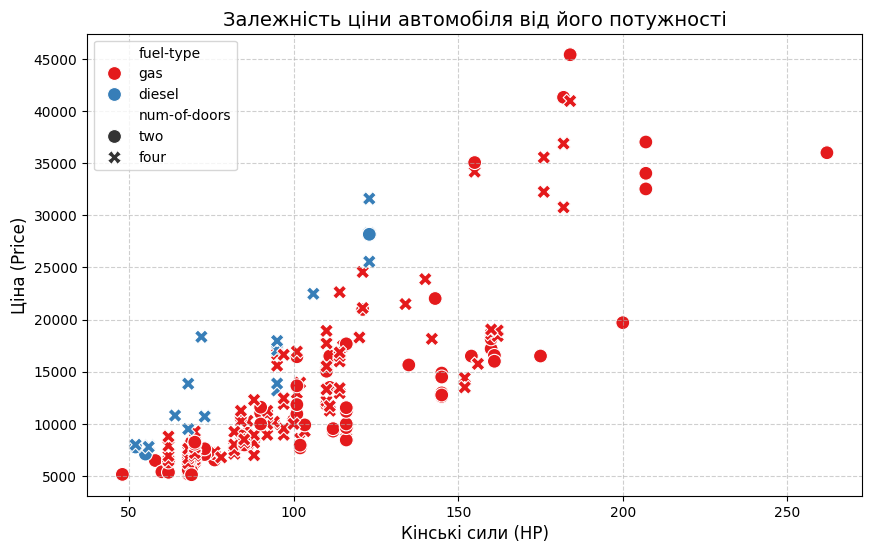

In [4]:
# 1. Графік залежності (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(x="horsepower", y="price", hue="fuel-type", style="num-of-doors", s=100, data=df, palette="Set1")
plt.title("Залежність ціни автомобіля від його потужності", fontsize=14)
plt.xlabel("Кінські сили (HP)", fontsize=12)
plt.ylabel("Ціна (Price)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

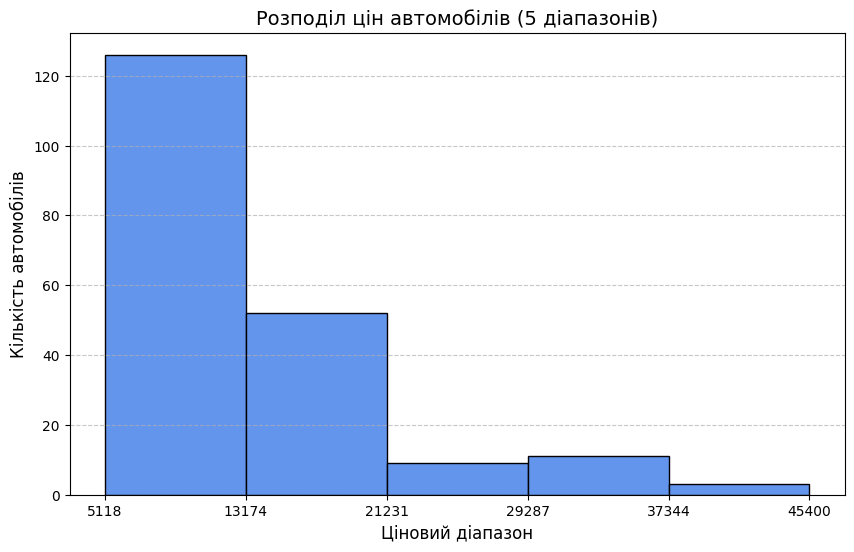

In [5]:
# 2. Гістограма у 5 діапазонах (Distribution)
plt.figure(figsize=(10, 6))
counts, bins, patches = plt.hist(df["price"], bins=5, color='cornflowerblue', edgecolor='black')
plt.title("Розподіл цін автомобілів (5 діапазонів)", fontsize=14)
plt.xlabel("Ціновий діапазон", fontsize=12)
plt.ylabel("Кількість автомобілів", fontsize=12)
plt.xticks(bins) # Відображаємо межі діапазонів на осі X
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

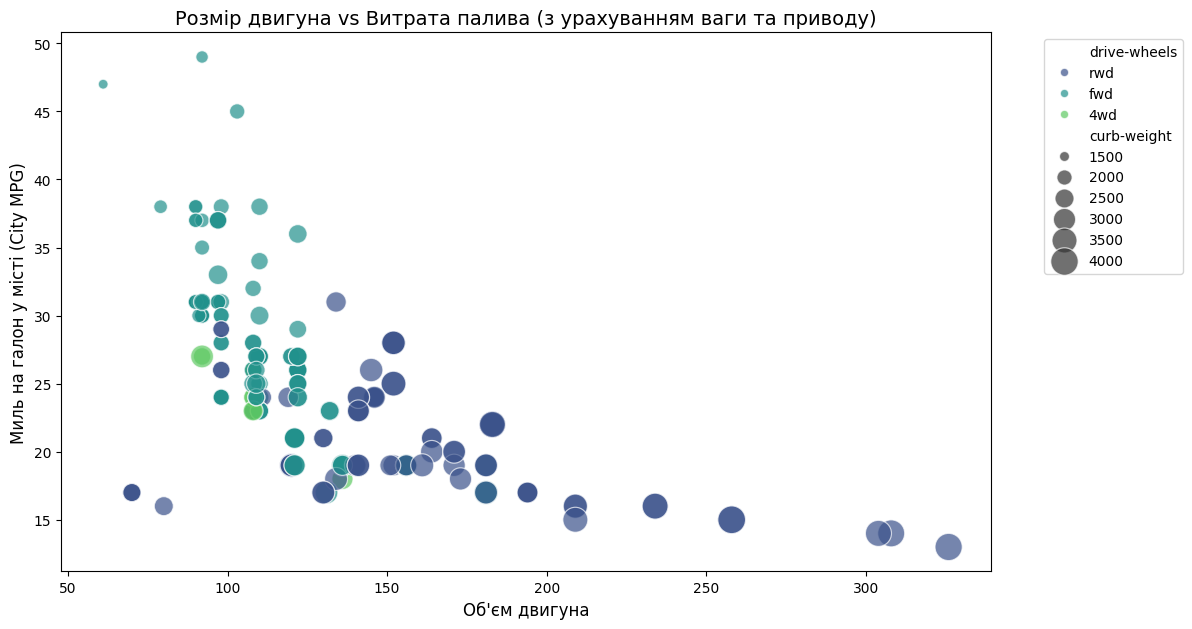

In [6]:
# 3. Багатовимірна візуалізація (Multi-dimensional Bubble Chart)
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x="engine-size", y="city-mpg",
    hue="drive-wheels", size="curb-weight",
    sizes=(50, 400), alpha=0.7, palette="viridis", data=df
)
plt.title("Розмір двигуна vs Витрата палива (з урахуванням ваги та приводу)", fontsize=14)
plt.xlabel("Об'єм двигуна", fontsize=12)
plt.ylabel("Миль на галон у місті (City MPG)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

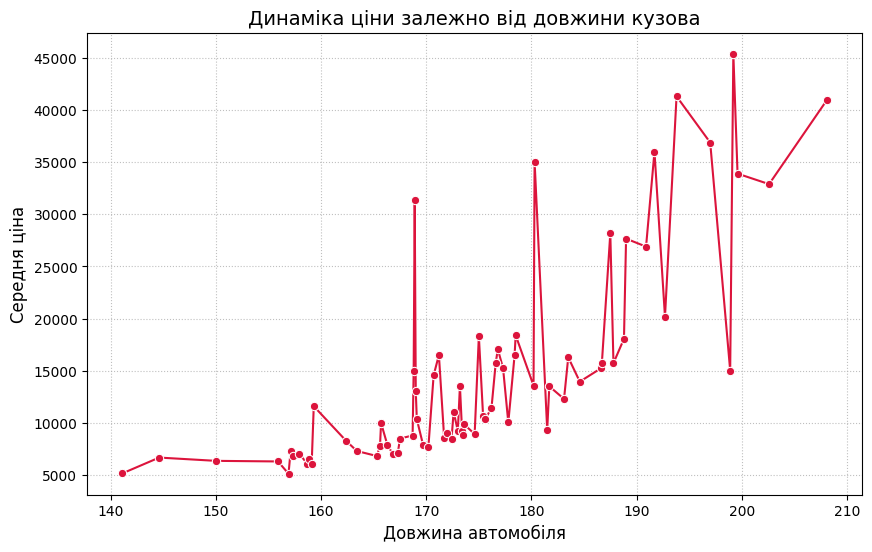

In [7]:
# 4. Залежність середньої ціни від довжини авто (Lineplot)
plt.figure(figsize=(10, 6))
sns.lineplot(x="length", y="price", data=df, color="crimson", errorbar=None, marker="o")
plt.title("Динаміка ціни залежно від довжини кузова", fontsize=14)
plt.xlabel("Довжина автомобіля", fontsize=12)
plt.ylabel("Середня ціна", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.8)
plt.show()

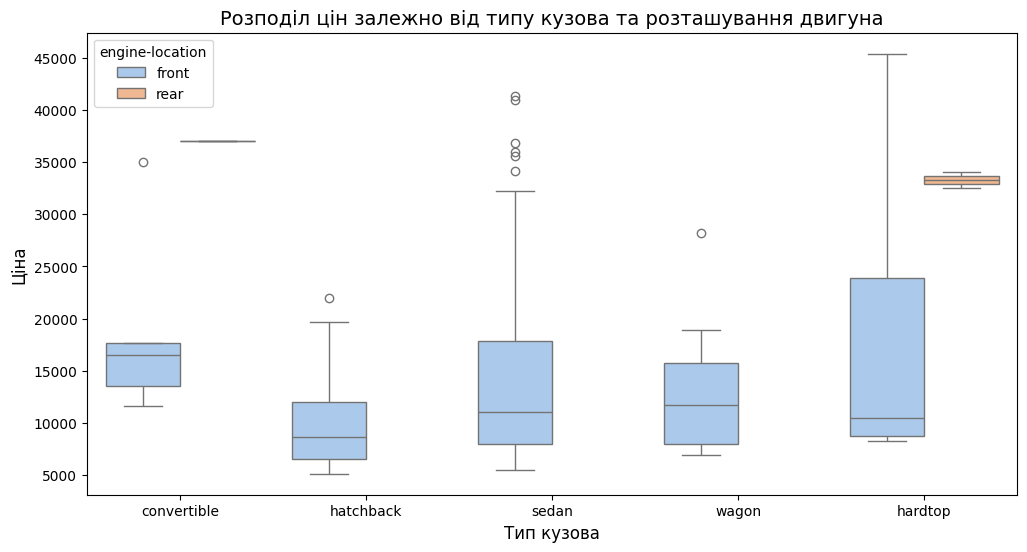

In [8]:
# 5. Аналіз цін за типом кузова та розташуванням двигуна (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(x="body-style", y="price", hue="engine-location", data=df, palette="pastel")
plt.title("Розподіл цін залежно від типу кузова та розташування двигуна", fontsize=14)
plt.xlabel("Тип кузова", fontsize=12)
plt.ylabel("Ціна", fontsize=12)
plt.show()

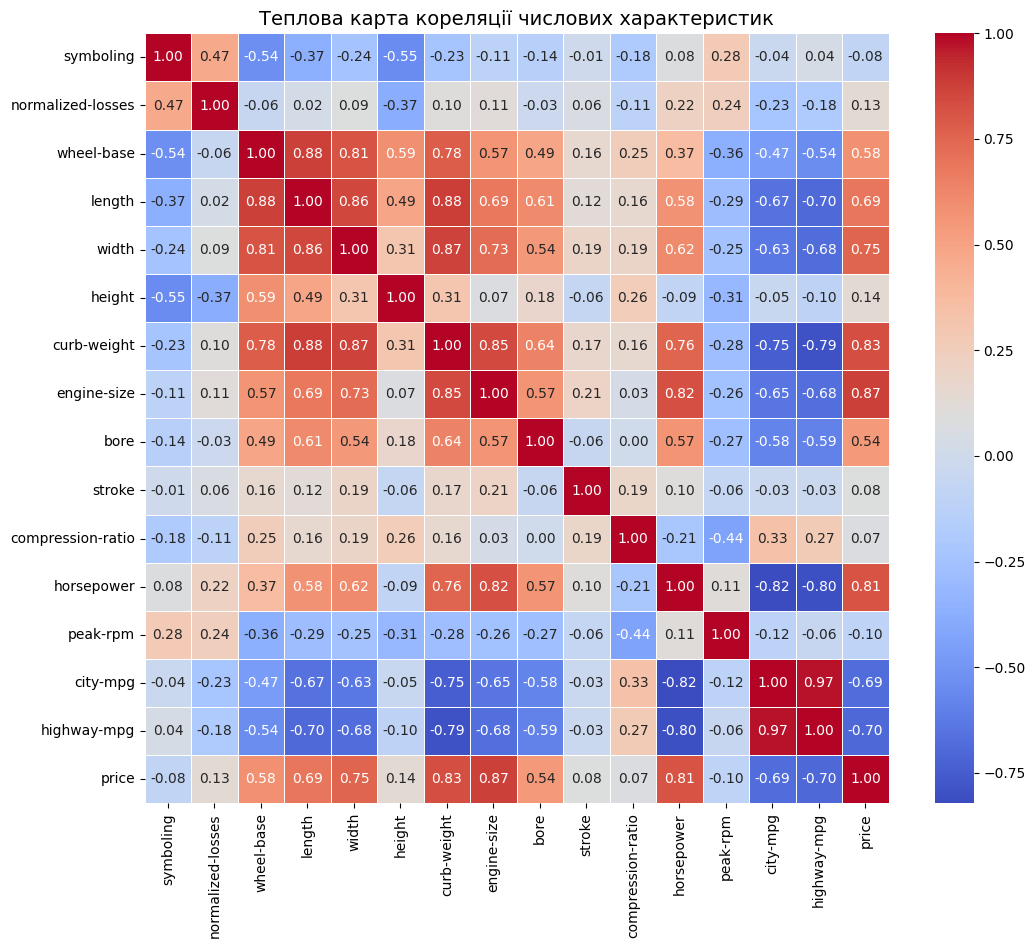

In [9]:
# 6. Кореляційна матриця числових атрибутів (Heatmap)
plt.figure(figsize=(12, 10))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Теплова карта кореляції числових характеристик", fontsize=14)
plt.show()